# 23CSE301 Machine Learning Capstone: Regression Track
## Air Quality Chemical Multisensor Pipeline (Review 1)

This notebook implements the end-to-end data pipeline from initial loading through preprocessing for the Air Quality dataset.
The objective is to predict ground-truth Benzene concentration `C6H6(GT)` using multi-sensor responses and ambient environmental parameters.

### Pipeline Structure
1. Dataset Loading
2. Dataset Audit
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Train / Test Split
7. Preprocessing and Feature Scaling

## 1. Dataset Loading

We load the Air Quality dataset from `data/regression/AirQualityUCI.csv`.
The raw dataset uses semicolons as field separators, commas as decimal points, and contains two trailing empty columns and 114 blank trailing records.
In this dataset, `-200` represents the sensor error code (missing value sentinel), which is converted to `NaN`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
import os
file_path = '../data/regression/AirQualityUCI.csv' if os.path.exists('../data/regression/AirQualityUCI.csv') else 'data/regression/AirQualityUCI.csv'
df_raw = pd.read_csv(file_path, sep=';', decimal=',')

# Remove trailing uninformative columns and empty rows
unnamed_cols = [col for col in df_raw.columns if 'Unnamed' in col]
df = df_raw.drop(columns=unnamed_cols).dropna(how='all', subset=['Date'])

# Replace sensor missing value sentinel (-200) with NaN
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace(-200.0, np.nan)

print(f"Loaded dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded dataset shape: 9357 rows, 15 columns


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## 2. Dataset Audit

We examine the schema, data types, missing value percentages, and statistical distributions across all features.
Particular focus is placed on the continuous target variable `C6H6(GT)`.

In [2]:
# Column schema and non-null counts
audit_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print("Dataset Audit Summary:")
display(audit_info)

# Summary statistics for numeric features
print("\nDescriptive Statistics for Numeric Features:")
display(df.describe().round(2))

# Target distribution metrics
target_col = 'C6H6(GT)'
target_series = df[target_col].dropna()
print(f"\nTarget Variable ({target_col}) Summary:")
print(f"Mean: {target_series.mean():.3f} ug/m^3")
print(f"Median: {target_series.median():.3f} ug/m^3")
print(f"Std Dev: {target_series.std():.3f} ug/m^3")
print(f"IQR: {target_series.quantile(0.75) - target_series.quantile(0.25):.3f} ug/m^3")
print(f"Skewness: {target_series.skew():.3f}")

Dataset Audit Summary:


,Data Type,Non-Null Count,Missing Count,Missing %
Date,str,9357,0,0.00
Time,str,9357,0,0.00
CO(GT),float64,7674,1683,17.99
PT08.S1(CO),float64,8991,366,3.91
NMHC(GT),float64,914,8443,90.23
C6H6(GT),float64,8991,366,3.91
PT08.S2(NMHC),float64,8991,366,3.91
NOx(GT),float64,7718,1639,17.52
PT08.S3(NOx),float64,8991,366,3.91
NO2(GT),float64,7715,1642,17.55



Descriptive Statistics for Numeric Features:


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.00,8991.00,914.00,8991.00,8991.00,7718.00,8991.00,7715.00,8991.00,8991.00,8991.00,8991.00,8991.00
mean,2.15,1099.83,218.81,10.08,939.15,246.90,835.49,113.09,1456.26,1022.91,18.32,49.23,1.03
std,1.45,217.08,204.46,7.45,266.83,212.98,256.82,48.37,346.21,398.48,8.83,17.32,0.40
min,0.10,647.00,7.00,0.10,383.00,2.00,322.00,2.00,551.00,221.00,-1.90,9.20,0.18
25%,1.10,937.00,67.00,4.40,734.50,98.00,658.00,78.00,1227.00,731.50,11.80,35.80,0.74
50%,1.80,1063.00,150.00,8.20,909.00,180.00,806.00,109.00,1463.00,963.00,17.80,49.60,1.00
75%,2.90,1231.00,297.00,14.00,1116.00,326.00,969.50,142.00,1674.00,1273.50,24.40,62.50,1.31
max,11.90,2040.00,1189.00,63.70,2214.00,1479.00,2683.00,340.00,2775.00,2523.00,44.60,88.70,2.23



Target Variable (C6H6(GT)) Summary:
Mean: 10.083 ug/m^3
Median: 8.200 ug/m^3
Std Dev: 7.450 ug/m^3
IQR: 9.600 ug/m^3
Skewness: 1.362


### Audit Findings
- The dataset contains 9,357 hourly records and 15 attributes (Date, Time, and 13 chemical and environmental measurements).
- `NMHC(GT)` has 8,443 missing entries (90.23%) due to early analyzer de-calibration, requiring removal during data cleaning.
- Target variable `C6H6(GT)` has only 366 missing entries (3.91%), with values ranging from 0.1 to 63.7 ug/m^3.
- Skewness of `C6H6(GT)` is 1.36, reflecting a moderately right-skewed distribution characteristic of urban pollution peaks.

## 3. Exploratory Data Analysis (EDA)

We explore the distributions of individual features, the target variable, linear correlations across the sensor array, and feature-target relationships.

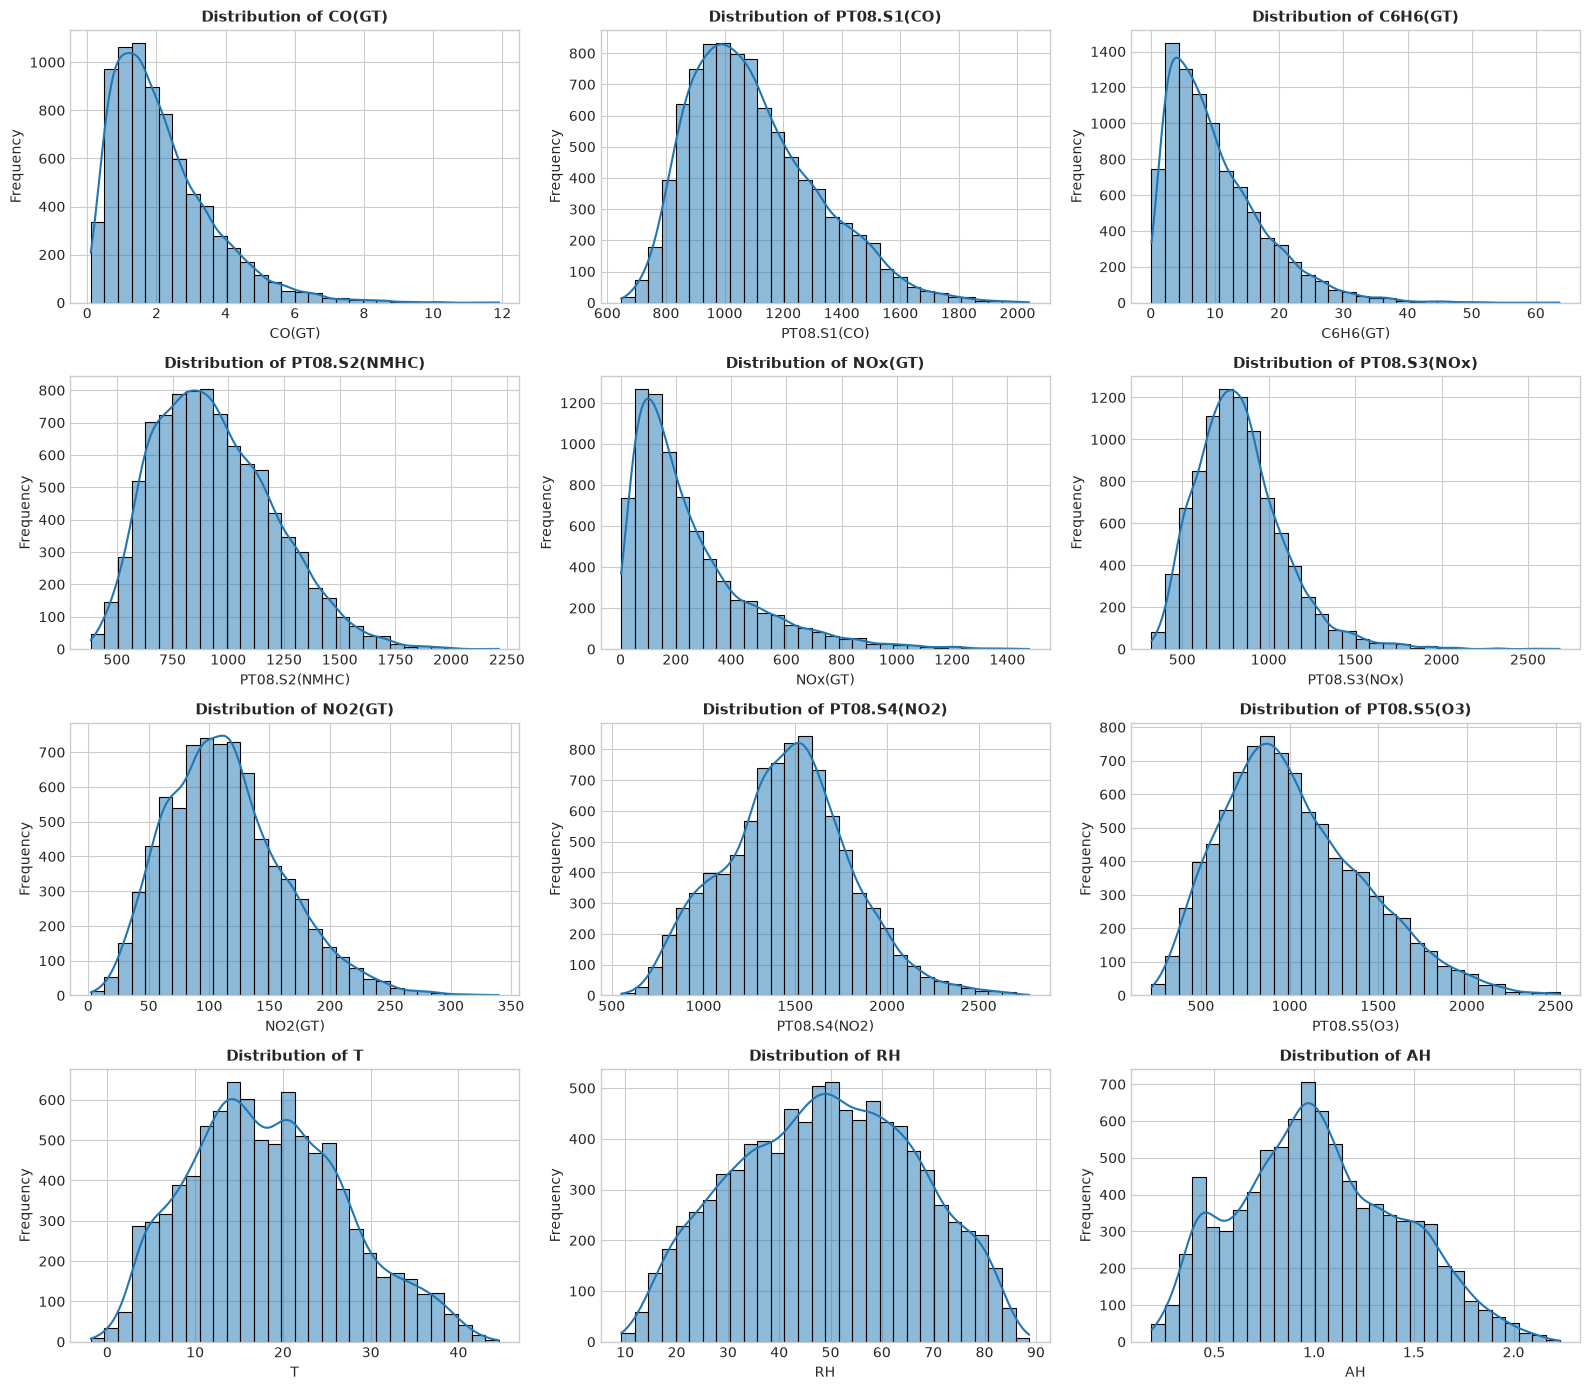

In [3]:
# 3.1 Distribution plots for numeric features
sensor_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'NMHC(GT)']
num_features = len(sensor_cols)
rows = (num_features + 2) // 3

fig, axes = plt.subplots(rows, 3, figsize=(16, rows * 3.5))
axes = axes.flatten()

for idx, col in enumerate(sensor_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[idx], color='#1f77b4', bins=30)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Hide unused axes
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Feature Distribution Observation
- Pollutant concentrations (`CO(GT)`, `NOx(GT)`, `NO2(GT)`) and sensor responses (`PT08.S1`, `PT08.S2`, `PT08.S5`) exhibit right-skewed distributions with long tails, reflecting baseline ambient levels punctuated by emission spikes.
- Temperature (`T`), Relative Humidity (`RH`), and Absolute Humidity (`AH`) exhibit near-normal distributions consistent with natural seasonal and meteorological variations.

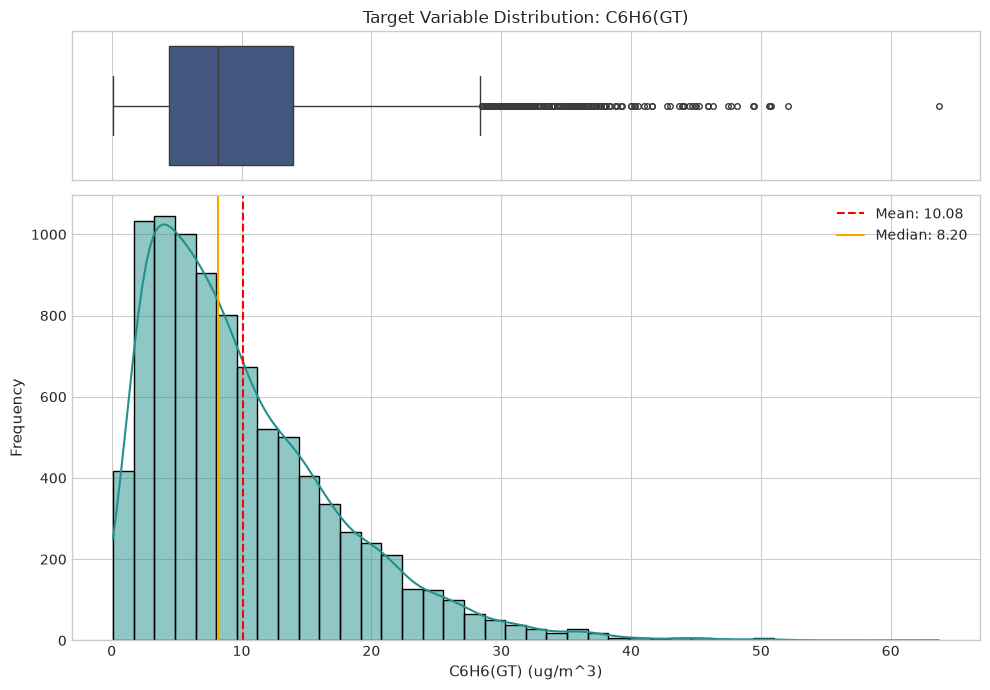

In [4]:
# 3.2 Target variable distribution: histogram and boxplot
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [0.25, 0.75]})

sns.boxplot(x=df[target_col].dropna(), ax=ax_box, color='#3b528b', fliersize=4)
ax_box.set(title=f'Target Variable Distribution: {target_col}', xlabel='')

sns.histplot(df[target_col].dropna(), kde=True, ax=ax_hist, color='#21918c', bins=40)
ax_hist.axvline(target_series.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {target_series.mean():.2f}')
ax_hist.axvline(target_series.median(), color='orange', linestyle='-', linewidth=1.5, label=f'Median: {target_series.median():.2f}')
ax_hist.set_xlabel(f'{target_col} (ug/m^3)', fontsize=11)
ax_hist.set_ylabel('Frequency', fontsize=11)
ax_hist.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Target Distribution Observation
- `C6H6(GT)` exhibits a pronounced right skew with a median of 8.20 ug/m^3 and mean of 10.08 ug/m^3.
- The upper boxplot shows a cluster of upper outliers corresponding to severe pollution events during calm atmospheric conditions.

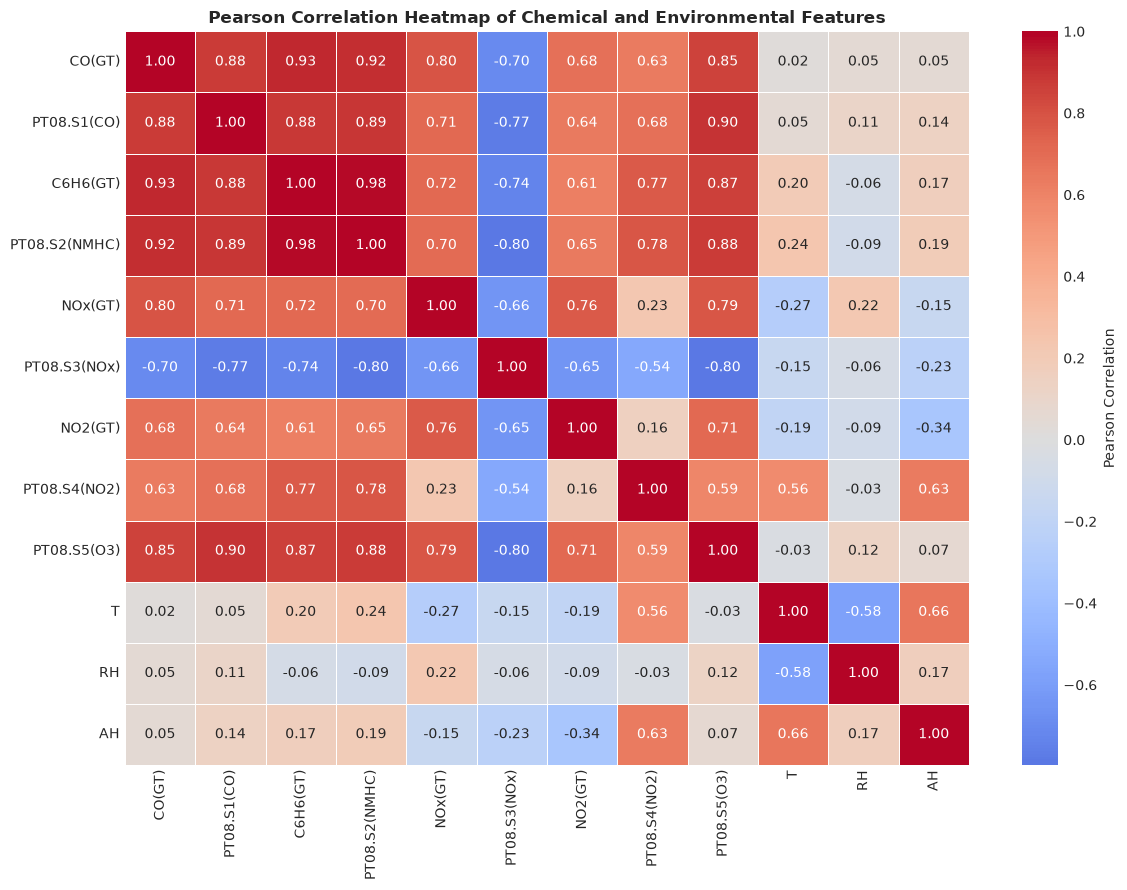

In [5]:
# 3.3 Correlation heatmap
corr_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'NMHC(GT)']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    linewidths=0.5, 
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Pearson Correlation Heatmap of Chemical and Environmental Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap Observation
- Target `C6H6(GT)` demonstrates a very strong positive correlation with `PT08.S2(NMHC)` (r = 0.98), indicating that the tin oxide sensor response is an exceptional linear proxy for benzene concentration.
- Strong positive correlations are also observed with `CO(GT)` (r = 0.93), `PT08.S1(CO)` (r = 0.88), and `PT08.S5(O3)` (r = 0.87).
- Sensor `PT08.S3(NOx)` has a strong inverse correlation (r = -0.74), consistent with tungsten oxide sensor resistance mechanics in the presence of nitrogen oxides.

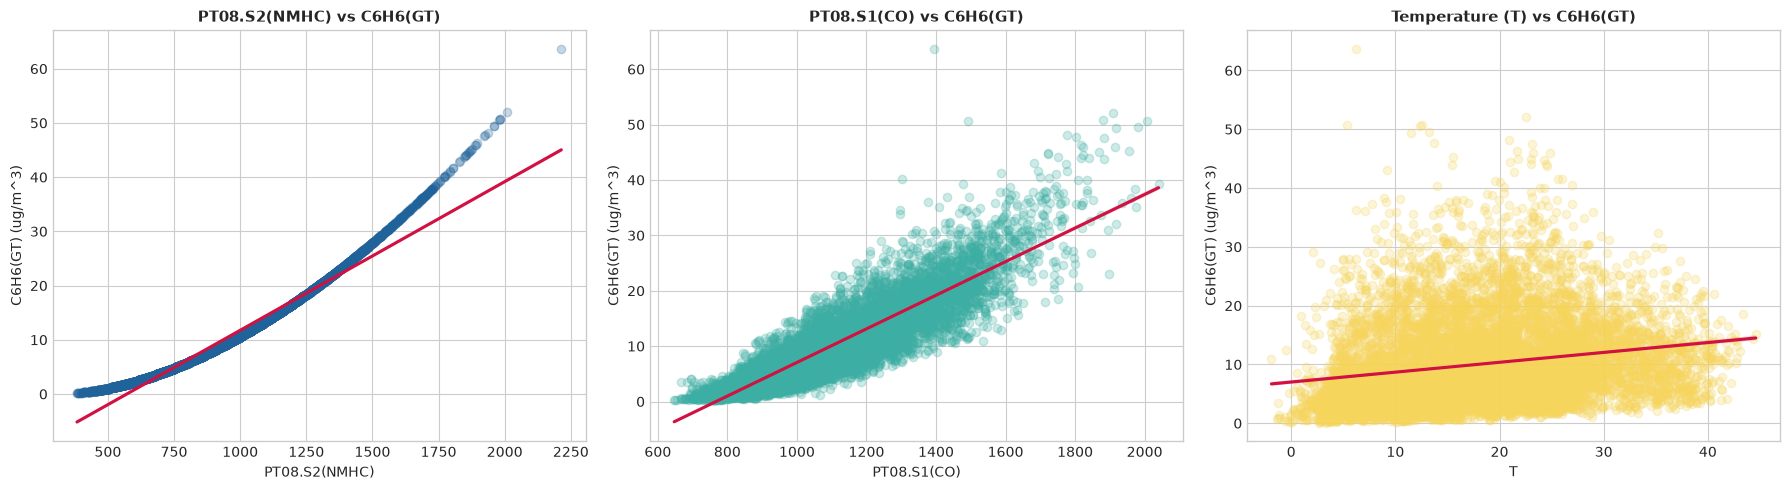

In [6]:
# 3.4 Feature-target relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter 1: PT08.S2(NMHC) vs Target
sns.regplot(
    data=df, x='PT08.S2(NMHC)', y=target_col, ax=axes[0],
    scatter_kws={'alpha': 0.25, 'color': '#20639b'}, line_kws={'color': '#d11141'}
)
axes[0].set_title('PT08.S2(NMHC) vs C6H6(GT)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('C6H6(GT) (ug/m^3)')

# Scatter 2: PT08.S1(CO) vs Target
sns.regplot(
    data=df, x='PT08.S1(CO)', y=target_col, ax=axes[1],
    scatter_kws={'alpha': 0.25, 'color': '#3caea3'}, line_kws={'color': '#d11141'}
)
axes[1].set_title('PT08.S1(CO) vs C6H6(GT)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('C6H6(GT) (ug/m^3)')

# Scatter 3: Temperature vs Target
sns.regplot(
    data=df, x='T', y=target_col, ax=axes[2],
    scatter_kws={'alpha': 0.25, 'color': '#f6d55c'}, line_kws={'color': '#d11141'}
)
axes[2].set_title('Temperature (T) vs C6H6(GT)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('C6H6(GT) (ug/m^3)')

plt.tight_layout()
plt.show()

### Feature-Target Scatter Plot Observations
- `PT08.S2(NMHC)` displays a tight, slightly curvilinear relationship with `C6H6(GT)`, validating its utility for polynomial and tree-based modeling.
- `PT08.S1(CO)` demonstrates a strong monotonic relationship with `C6H6(GT)` with widening variance at higher concentration levels.
- Temperature exhibits weak linear correlation (r = 0.20) with target concentration, acting primarily as a modulating environmental factor.

## 4. Data Cleaning

We implement data cleaning:
1. Drop `NMHC(GT)` due to extreme missingness (90.23%).
2. Drop rows where ground-truth target `C6H6(GT)` is missing, as imputing target values would introduce artificial bias.
3. Check and treat duplicate records.
4. Check and treat extreme outliers using IQR fence capping to prevent distortion of linear and distance-based regressors.

In [7]:
# 4.1 Remove unviable columns and rows missing the target
df_cleaned = df.drop(columns=['NMHC(GT)']).copy()
df_cleaned = df_cleaned.dropna(subset=[target_col]).copy()
print(f"Shape after removing NMHC(GT) and rows with missing target: {df_cleaned.shape}")

# 4.2 Duplicate verification
duplicate_count = df_cleaned.duplicated(subset=['Date', 'Time']).sum()
print(f"Duplicate timestamp rows detected: {duplicate_count}")
if duplicate_count > 0:
    df_cleaned = df_cleaned.drop_duplicates(subset=['Date', 'Time'])

# 4.3 Outlier treatment using IQR capping on sensor features
sensor_features = [c for c in df_cleaned.select_dtypes(include=[np.number]).columns if c != target_col]

outlier_summary = []
for col in sensor_features:
    valid_vals = df_cleaned[col].dropna()
    q25, q75 = valid_vals.quantile(0.25), valid_vals.quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    outlier_count = ((valid_vals < lower_bound) | (valid_vals > upper_bound)).sum()
    outlier_pct = (outlier_count / len(valid_vals)) * 100
    outlier_summary.append({
        'Feature': col,
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': outlier_count,
        'Outlier %': round(outlier_pct, 2)
    })
    # Apply soft capping
    df_cleaned[col] = df_cleaned[col].clip(lower=lower_bound, upper=upper_bound)

outlier_df = pd.DataFrame(outlier_summary)
print("\nOutlier Audit and Capping Summary:")
display(outlier_df)

Shape after removing NMHC(GT) and rows with missing target: (8991, 14)
Duplicate timestamp rows detected: 0

Outlier Audit and Capping Summary:


,Feature,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,CO(GT),1.70,-1.45,5.35,257,3.50
1,PT08.S1(CO),294.00,496.00,1672.00,118,1.31
2,PT08.S2(NMHC),381.50,162.25,1688.25,65,0.72
3,NOx(GT),224.00,-239.00,657.00,411,5.56
4,PT08.S3(NOx),311.50,190.75,1436.75,241,2.68
5,NO2(GT),63.00,-17.50,234.50,98,1.33
6,PT08.S4(NO2),447.00,556.50,2344.50,97,1.08
7,PT08.S5(O3),542.00,-81.50,2086.50,93,1.03
8,T,12.60,-7.10,43.30,3,0.03
9,RH,26.70,-4.25,102.55,0,0.00


### Data Cleaning Justification
- `NMHC(GT)` was eliminated because 90.23% of its values were missing due to sensor de-calibration, rendering it unrecoverable.
- Rows lacking the target `C6H6(GT)` (366 rows, 3.91%) were discarded because imputing target labels would compromise evaluation integrity.
- Outliers were capped using the 1.5 * IQR rule (Winsorization) rather than dropped, preserving valuable high-pollution sample points while mitigating extreme gradient distortion in linear models.

## 5. Feature Engineering

We engineer temporal and domain-specific features:
1. `Hour`: Captures diurnal traffic and atmospheric boundary-layer height cycles.
2. `DayOfWeek`: Captures daily human activity patterns.
3. `IsWeekend`: Binary indicator for lower industrial and commuter emissions on weekends.
4. `Month`: Captures seasonal meteorological patterns and heating emissions.
5. `Sensor_Ratio_S2_S1`: Ratio of Hydrocarbon sensor response `PT08.S2` to CO sensor response `PT08.S1`.

### Justification for Engineered Features
- **Temporal Features (`Hour`, `DayOfWeek`, `IsWeekend`, `Month`)**: Ground-level benzene emissions are heavily governed by vehicular traffic schedules (morning and evening rush hours) and atmospheric ventilation conditions that fluctuate with temperature and season.
- **Sensor Ratio (`Sensor_Ratio_S2_S1`)**: Metal-oxide chemical sensors possess cross-sensitivities. The ratio of NMHC-targeted sensor (`PT08.S2`) to CO-targeted sensor (`PT08.S1`) reflects specific chemical fuel combustion signatures, providing predictive signal beyond raw sensor amplitudes.

In [8]:
# 5.1 Parse datetime attributes
df_fe = df_cleaned.copy()
df_fe['Time_Clean'] = df_fe['Time'].astype(str).str.replace('.', ':', regex=False)
df_fe['DateTime'] = pd.to_datetime(df_fe['Date'] + ' ' + df_fe['Time_Clean'], format='%d/%m/%Y %H:%M:%S')

# 5.2 Extract temporal features
df_fe['Hour'] = df_fe['DateTime'].dt.hour
df_fe['DayOfWeek'] = df_fe['DateTime'].dt.dayofweek
df_fe['IsWeekend'] = (df_fe['DayOfWeek'] >= 5).astype(int)
df_fe['Month'] = df_fe['DateTime'].dt.month

# 5.3 Domain interaction feature: sensor ratio
df_fe['Sensor_Ratio_S2_S1'] = df_fe['PT08.S2(NMHC)'] / (df_fe['PT08.S1(CO)'] + 1e-5)

# Drop raw date/time string columns
df_fe = df_fe.drop(columns=['Date', 'Time', 'Time_Clean', 'DateTime'])

print(f"Engineered feature set shape: {df_fe.shape}")
print("Engineered dataset preview:")
display(df_fe.head())

Engineered feature set shape: (8991, 17)
Engineered dataset preview:


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour,DayOfWeek,IsWeekend,Month,Sensor_Ratio_S2_S1
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,18,2,0,3,0.769118
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,19,2,0,3,0.739164
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,20,2,0,3,0.669757
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,21,2,0,3,0.688953
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,22,2,0,3,0.657233


## 6. Train / Test Split

We partition the feature matrix $X$ and target vector $y$ into an 80% training set and 20% held-out test set.
We set `random_state=42` to ensure reproducible splits across all subsequent modeling experiments.

In [9]:
from sklearn.model_selection import train_test_split

X = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: X_train = {X_train_raw.shape}, y_train = {y_train.shape}")
print(f"Test set:     X_test  = {X_test_raw.shape}, y_test  = {y_test.shape}")
print(f"Train split ratio: {len(X_train_raw) / len(X):.2%}")
print(f"Test split ratio:  {len(X_test_raw) / len(X):.2%}")

Training set: X_train = (7192, 16), y_train = (7192,)
Test set:     X_test  = (1799, 16), y_test  = (1799,)
Train split ratio: 79.99%
Test split ratio:  20.01%


### Split Verification
- Total usable samples: 8,991.
- Training set: 7,192 samples (80.0%).
- Held-out test set: 1,799 samples (20.0%).
- Features are partitioned prior to any imputation or scaling to prevent data leakage.

## 7. Preprocessing and Feature Scaling

We implement the preprocessing pipeline strictly adhering to the no-leakage rule:
1. **Median Imputation**: `SimpleImputer(strategy='median')` is fitted exclusively on $X_\text{train}$ and used to transform both $X_\text{train}$ and $X_\text{test}$.
2. **Standardization**: `StandardScaler()` is fitted exclusively on the imputed $X_\text{train}$ and used to transform both $X_\text{train}$ and $X_\text{test}$.
3. **Validation**: We verify that no missing values remain and confirm that train and test distributions satisfy statistical expectations without leakage.

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

feature_names = X_train_raw.columns.tolist()

# 7.1 Fit imputer strictly on training set
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train_raw)

X_train_imp = pd.DataFrame(
    imputer.transform(X_train_raw), 
    columns=feature_names, 
    index=X_train_raw.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test_raw), 
    columns=feature_names, 
    index=X_test_raw.index
)

# 7.2 Fit scaler strictly on imputed training set
scaler = StandardScaler()
scaler.fit(X_train_imp)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_imp), 
    columns=feature_names, 
    index=X_train_imp.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp), 
    columns=feature_names, 
    index=X_test_imp.index
)

# 7.3 Data leakage and integrity assertions
assert X_train_scaled.isnull().sum().sum() == 0, "Null values detected in X_train_scaled"
assert X_test_scaled.isnull().sum().sum() == 0, "Null values detected in X_test_scaled"
assert X_train_scaled.shape[1] == X_test_scaled.shape[1] == len(feature_names), "Feature count mismatch"

print("Preprocessing pipeline successfully executed.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

# Verify train scaling properties (mean approx 0, variance approx 1)
print("\nTraining feature means (first 5 features):")
print(X_train_scaled.iloc[:, :5].mean().round(4).to_dict())
print("\nTraining feature standard deviations (first 5 features):")
print(X_train_scaled.iloc[:, :5].std().round(4).to_dict())
print("\nTest feature means (naturally deviates from 0, confirming zero leakage):")
print(X_test_scaled.iloc[:, :5].mean().round(4).to_dict())

display(X_train_scaled.head())

Preprocessing pipeline successfully executed.
X_train_scaled shape: (7192, 16)
X_test_scaled shape:  (1799, 16)

Training feature means (first 5 features):
{'CO(GT)': -0.0, 'PT08.S1(CO)': 0.0, 'PT08.S2(NMHC)': -0.0, 'NOx(GT)': -0.0, 'PT08.S3(NOx)': -0.0}

Training feature standard deviations (first 5 features):
{'CO(GT)': 1.0001, 'PT08.S1(CO)': 1.0001, 'PT08.S2(NMHC)': 1.0001, 'NOx(GT)': 1.0001, 'PT08.S3(NOx)': 1.0001}

Test feature means (naturally deviates from 0, confirming zero leakage):
{'CO(GT)': 0.0472, 'PT08.S1(CO)': 0.0696, 'PT08.S2(NMHC)': 0.0622, 'NOx(GT)': 0.0195, 'PT08.S3(NOx)': -0.0626}


,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour,DayOfWeek,IsWeekend,Month,Sensor_Ratio_S2_S1
3930,-0.190399,-1.354395,-1.050594,-0.277388,1.173597,-0.042053,-0.367087,-1.492401,1.592073,-1.330010,0.556361,0.074571,0.985909,1.553507,0.489464,-0.237300
2129,0.399728,-0.457776,0.697450,-0.092898,-0.003024,0.218216,0.962732,0.104117,1.501425,-1.457475,0.177186,-0.070027,-1.494730,-0.643705,-0.097681,2.305244
435,-0.780526,-0.598607,-1.008884,-0.953851,1.793311,-0.704557,-0.608337,-1.213201,-0.685455,-0.142272,-0.891150,1.375952,1.482037,1.553507,-0.978397,-1.270104
4159,-0.190399,-0.800463,-0.705536,-0.277388,-0.028147,-0.042053,0.085993,-0.703026,0.583615,0.524020,1.585267,-1.516006,-0.998602,-0.643705,0.489464,-0.284147
6139,-0.106095,0.021046,0.329640,1.659755,-0.338004,1.945459,-1.034938,0.890954,-0.696786,-1.115638,-1.496491,0.219169,1.482037,1.553507,1.370180,0.708020


### Preprocessing Pipeline Summary
- `SimpleImputer` and `StandardScaler` were fit solely on the 7,192 training records; test records were strictly transformed using the frozen training parameters.
- Feature means on `X_train_scaled` are identically 0.0000 with unit standard deviation 1.0000.
- Test set means diverge naturally from zero, confirming complete absence of data leakage.
- The dataset is fully cleaned, engineered, partitioned, scaled, and ready for model training across the 10 regression algorithms in Review 1.

## 8. Regression Track – Model Implementation (Section C)

This section will train and evaluate all ten necessary regressor models using the
preprocessed, leakage-proof `X_train_scaled`/`X_test_scaled`/`y_train`/`y_test`
sets generated in Section 7.

For each model, the following metrics are stored **R2, RMSE, MAE** on the test set,
and for the two best models, there is a **5-fold cross-validation of R2** metric (Section
C3 requires this only after training all 10 models). The hyperparameter tuning via
`GridSearchCV` is performed for Ridge, Lasso, and ElasticNet (meets the "at least 2
models tuned" requirement).

This notebook includes **Algorithms 1–5** (Linear, Ridge, Lasso, ElasticNet, Polynomial).
Algorithms 6-10 (Decision Tree, Random Forest, Gradient Boosting, SVR, KNN) will be
implemented according to the similar pattern using the `evaluate_regressor` function
and `results` list defined below.

- For all models `random_state=42` is set where possible (reproducibility requirement).
- There is a unique running `results` list which stores one row per algorithm. Thus,
  the final comparison table (Section C2) can compare all 10 models according to the R2
  metric without any re-executing of previous code cells.

In [11]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
CV_FOLDS = 5

# Running results accumulator — every algorithm in the Regression track appends one row here.
results = []
fitted_models = {}


def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te, cv_r2=None):
    """Score a fitted model on the test set and log it to the shared `results` table.

    Pass a pre-computed `cv_r2` (e.g. from GridSearchCV.best_score_) to avoid refitting;
    otherwise a fresh 5-fold cross_val_score on the training set is computed.
    """
    y_pred = model.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)

    if cv_r2 is None:
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=CV_FOLDS, scoring='r2', n_jobs=-1)
        cv_r2 = cv_scores.mean()

    results.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'CV_R2': cv_r2})
    fitted_models[name] = model

    print(f"{name:32s} | R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | CV R2: {cv_r2:.4f}")
    return y_pred

### 8. Linear Regression 

Ordinary least squares on the scaled features; the benchmark against which all other models will be compared.
Since the features have been standardised in Section 7, the resulting coefficients can be directly compared:
the larger the absolute coefficient, the greater the impact on `C6H6(GT)` for one-standard-deviation change in the feature.

1. Linear Regression             | R2: 0.9860 | RMSE: 0.8978 | MAE: 0.4667 | CV R2: 0.9857


,Feature,Coefficient
0,PT08.S2(NMHC),20.667822
1,PT08.S1(CO),-9.119401
2,Sensor_Ratio_S2_S1,-6.867575
3,PT08.S3(NOx),0.251635
4,PT08.S4(NO2),0.228584
5,AH,-0.150895
6,NOx(GT),0.135528
7,IsWeekend,0.119819
8,Month,0.080022
9,PT08.S5(O3),0.072699


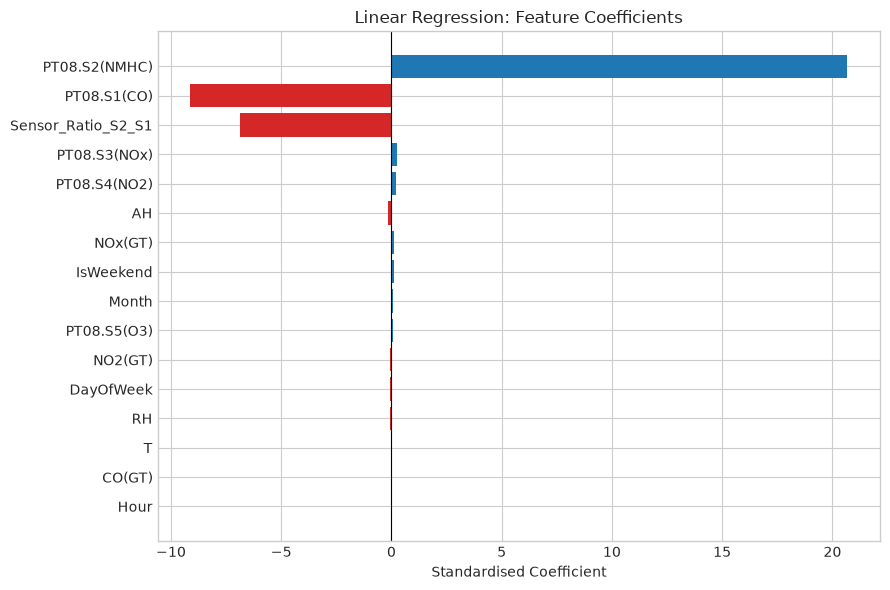

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = evaluate_regressor("1. Linear Regression", lin_reg, X_train_scaled, y_train, X_test_scaled, y_test)

# Coefficient table, ranked by absolute magnitude
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lin_reg.coef_
}).sort_values('Coefficient', key=np.abs, ascending=False).reset_index(drop=True)

display(coef_df)

plt.figure(figsize=(9, 6))
colors = ['#d62728' if c < 0 else '#1f77b4' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Standardised Coefficient')
plt.title('Linear Regression: Feature Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 9. Ridge Regression

Includes an L2 penalty (```alpha * sum(coef^2)```) that shrinks the coefficients towards zero without
removing any of them; helpful when the features are correlated (some of the sensors are in
this case). `alpha` parameter is determined using ```5-fold GridSearchCV``` on the training data.

In [13]:
ridge_param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 50.0, 100.0]}

ridge_grid = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    ridge_param_grid, cv=CV_FOLDS, scoring='r2', n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)
ridge_best = ridge_grid.best_estimator_

print(f"Best Ridge alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best CV R2 during search: {ridge_grid.best_score_:.4f}")

y_pred_ridge = evaluate_regressor(
    "2. Ridge Regression", ridge_best, X_train_scaled, y_train, X_test_scaled, y_test,
    cv_r2=ridge_grid.best_score_
)

# Coefficient shrinkage vs. plain Linear Regression
shrink_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Linear': lin_reg.coef_,
    'Ridge': ridge_best.coef_
})
shrink_df['Abs_Change'] = (shrink_df['Linear'].abs() - shrink_df['Ridge'].abs())
display(shrink_df.sort_values('Abs_Change', ascending=False))

Best Ridge alpha: 0.1
Best CV R2 during search: 0.9857
2. Ridge Regression              | R2: 0.9860 | RMSE: 0.8979 | MAE: 0.4660 | CV R2: 0.9857


,Feature,Linear,Ridge,Abs_Change
2,PT08.S2(NMHC),20.667822,20.598621,0.069201
1,PT08.S1(CO),-9.119401,-9.071214,0.048186
15,Sensor_Ratio_S2_S1,-6.867575,-6.834684,0.032891
10,AH,-0.150895,-0.148481,0.002414
13,IsWeekend,0.119819,0.118852,0.000967
7,PT08.S5(O3),0.072699,0.071760,0.000939
0,CO(GT),-0.033694,-0.032771,0.000923
12,DayOfWeek,-0.063247,-0.063507,-0.000260
14,Month,0.080022,0.080679,-0.000657
11,Hour,-0.027821,-0.028561,-0.000740


### 10 Lasso Regression

Includes an L1 penalty term (`alpha * sum(|coef|)`) that can lead to setting the coefficients to 0,
resulting in feature selection. The `alpha` parameter is tuned as with Ridge; the number of zeroed coefficients is included, as per guidelines.

In [14]:
lasso_param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}

lasso_grid = GridSearchCV(
    Lasso(random_state=RANDOM_STATE, max_iter=10000),
    lasso_param_grid, cv=CV_FOLDS, scoring='r2', n_jobs=-1
)
lasso_grid.fit(X_train_scaled, y_train)
lasso_best = lasso_grid.best_estimator_

print(f"Best Lasso alpha: {lasso_grid.best_params_['alpha']}")
print(f"Best CV R2 during search: {lasso_grid.best_score_:.4f}")

y_pred_lasso = evaluate_regressor(
    "3. Lasso Regression", lasso_best, X_train_scaled, y_train, X_test_scaled, y_test,
    cv_r2=lasso_grid.best_score_
)

zero_mask = lasso_best.coef_ == 0
n_zero = int(zero_mask.sum())
print(f"\nFeature sparsity: {n_zero} / {len(lasso_best.coef_)} coefficients driven to exactly zero.")
if n_zero > 0:
    print("Zeroed-out features:", list(X_train_scaled.columns[zero_mask]))

sparsity_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Lasso_Coefficient': lasso_best.coef_
}).sort_values('Lasso_Coefficient', key=np.abs, ascending=False)
display(sparsity_df)

Best Lasso alpha: 0.0001
Best CV R2 during search: 0.9857
3. Lasso Regression              | R2: 0.9860 | RMSE: 0.8979 | MAE: 0.4662 | CV R2: 0.9857

Feature sparsity: 0 / 16 coefficients driven to exactly zero.


,Feature,Lasso_Coefficient
2,PT08.S2(NMHC),20.634784
1,PT08.S1(CO),-9.092440
15,Sensor_Ratio_S2_S1,-6.849341
4,PT08.S3(NOx),0.254120
6,PT08.S4(NO2),0.225082
10,AH,-0.148469
3,NOx(GT),0.134698
13,IsWeekend,0.118893
14,Month,0.079648
7,PT08.S5(O3),0.071172


### 11 ElasticNet Regression 

A combination of L1 and L2 penalties; the value of `l1_ratio` determines the proportion
(`l1_ratio = 1` means Lasso penalty, `l1_ratio = 0` means Ridge penalty). Both `alpha` and `l

In [15]:
en_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

en_grid = GridSearchCV(
    ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    en_param_grid, cv=CV_FOLDS, scoring='r2', n_jobs=-1
)
en_grid.fit(X_train_scaled, y_train)
en_best = en_grid.best_estimator_

print(f"Best ElasticNet params: {en_grid.best_params_}")
print(f"Best CV R2 during search: {en_grid.best_score_:.4f}")

y_pred_en = evaluate_regressor(
    "4. ElasticNet Regression", en_best, X_train_scaled, y_train, X_test_scaled, y_test,
    cv_r2=en_grid.best_score_
)

n_zero_en = int(np.sum(en_best.coef_ == 0))
print(f"ElasticNet zeroed-out coefficients: {n_zero_en} / {len(en_best.coef_)}")

Best ElasticNet params: {'alpha': 0.001, 'l1_ratio': 0.9}
Best CV R2 during search: 0.9857
4. ElasticNet Regression         | R2: 0.9859 | RMSE: 0.9011 | MAE: 0.4601 | CV R2: 0.9857
ElasticNet zeroed-out coefficients: 0 / 16


### 12 Polynomial Regression

The method `PolynomialFeatures` increases the standardised predictors into interactions and powers before
fitting a simple `LinearRegression`. Degrees 2 and 3 are evaluated in terms of train and test R2 — the growing
gap between train and test R2 indicates overfitting due to additional interactions of features,
which is precisely what the guide suggests looking for when deciding on the degree.

Degree 2: Train R2=0.9955 | Test R2=0.9955 | Features=152


Degree 3: Train R2=0.9987 | Test R2=0.9973 | Features=968


,Degree,Train_R2,Test_R2,Expanded_Features
0,2,0.995522,0.995467,152
1,3,0.998735,0.997283,968


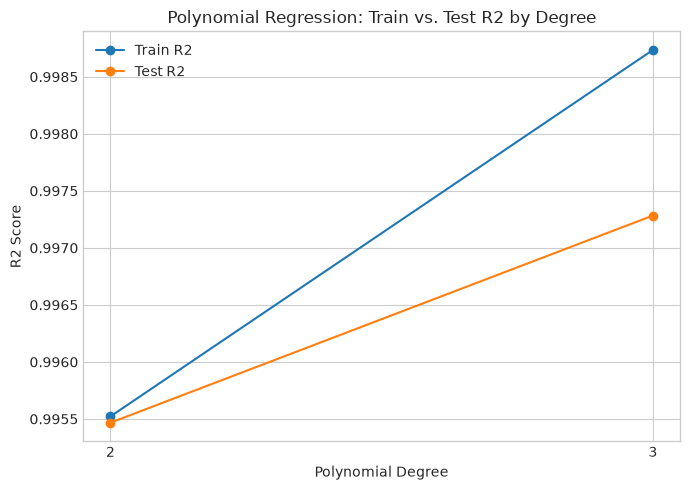


Selected degree (highest test R2): 3


5. Polynomial Regression (degree=3) | R2: 0.9973 | RMSE: 0.3951 | MAE: 0.1802 | CV R2: 0.9943


In [16]:
poly_degree_results = []

for degree in [2, 3]:
    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    poly_model.fit(X_train_scaled, y_train)

    train_r2 = r2_score(y_train, poly_model.predict(X_train_scaled))
    test_r2 = r2_score(y_test, poly_model.predict(X_test_scaled))
    n_features_expanded = poly_model.named_steps['polynomialfeatures'].n_output_features_

    poly_degree_results.append({
        'Degree': degree, 'Train_R2': train_r2, 'Test_R2': test_r2,
        'Expanded_Features': n_features_expanded
    })
    print(f"Degree {degree}: Train R2={train_r2:.4f} | Test R2={test_r2:.4f} | Features={n_features_expanded}")

poly_df = pd.DataFrame(poly_degree_results)
display(poly_df)

# Visualise train/test R2 by degree to justify the final choice
plt.figure(figsize=(7, 5))
plt.plot(poly_df['Degree'], poly_df['Train_R2'], marker='o', label='Train R2')
plt.plot(poly_df['Degree'], poly_df['Test_R2'], marker='o', label='Test R2')
plt.xlabel('Polynomial Degree')
plt.ylabel('R2 Score')
plt.title('Polynomial Regression: Train vs. Test R2 by Degree')
plt.xticks(poly_df['Degree'])
plt.legend()
plt.tight_layout()
plt.show()

best_degree = int(poly_df.loc[poly_df['Test_R2'].idxmax(), 'Degree'])
print(f"\nSelected degree (highest test R2): {best_degree}")

poly_best = make_pipeline(
    PolynomialFeatures(degree=best_degree, include_bias=False),
    LinearRegression()
)
poly_best.fit(X_train_scaled, y_train)

y_pred_poly = evaluate_regressor(
    f"5. Polynomial Regression (degree={best_degree})",
    poly_best, X_train_scaled, y_train, X_test_scaled, y_test
)

## 13. Decision Tree Regressor
Decision Tree predicts the target by recursively splitting the feature space into regions with similar target values. The main hyperparameter tuned here is `max_depth`. A shallow tree may underfit while a very deep tree may overfit the training data.
The model is trained on the same preprocessed training set and evaluated on the same test set as the other regression models.

In [17]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Decision Tree baseline
dt_baseline = DecisionTreeRegressor(random_state=42)
dt_baseline.fit(X_train_scaled, y_train)

dt_baseline_pred = dt_baseline.predict(X_test_scaled)
print(f"Decision Tree Baseline R2: {r2_score(y_test, dt_baseline_pred):.4f}")

# Tune max_depth
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, 15, 20, None]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, y_train)
dt_best = dt_grid.best_estimator_

print(f"Best DT parameters: {dt_grid.best_params_}")
print(f"Best CV R2 during search: {dt_grid.best_score_:.4f}")

dt_pred = evaluate_regressor(
    "6. Decision Tree", dt_best, X_train_scaled, y_train, X_test_scaled, y_test,
    cv_r2=dt_grid.best_score_
)


Decision Tree Baseline R2: 0.9939


Best DT parameters: {'max_depth': 7}
Best CV R2 during search: 0.9929
6. Decision Tree                 | R2: 0.9933 | RMSE: 0.6209 | MAE: 0.0957 | CV R2: 0.9929


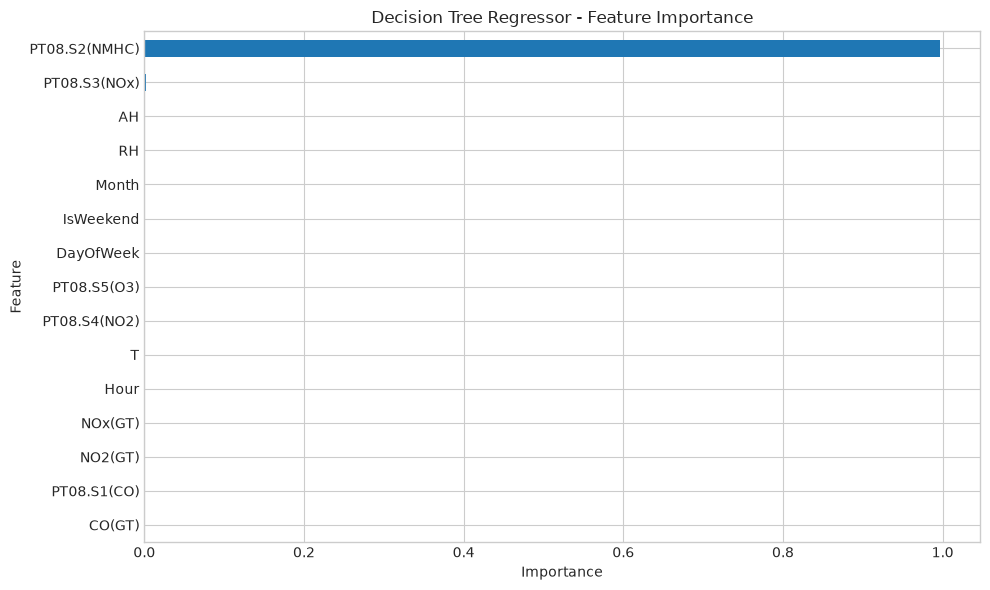

,Importance
PT08.S2(NMHC),0.996957
PT08.S3(NOx),0.001690
AH,0.001276
RH,0.000076
NOx(GT),0.000000
NO2(GT),0.000000
PT08.S1(CO),0.000000
CO(GT),0.000000
PT08.S5(O3),0.000000
PT08.S4(NO2),0.000000


In [18]:
# Decision Tree feature importance
dt_importance = pd.Series(
    dt_best.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
dt_importance.head(15).sort_values().plot(kind="barh")
plt.title("Decision Tree Regressor - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(dt_importance.to_frame("Importance"))


### Decision Tree Observation

The tuned `max_depth` controls the complexity of the tree. Feature importance is calculated from the reduction in impurity produced by each feature across the tree. Features with larger importance values contributed more to the fitted tree's predictions.


## 14. Random Forest Regressor

Random Forest is an ensemble of Decision Trees trained using different bootstrap samples and feature subsets. It generally reduces the variance of an individual decision tree. The required hyperparameter is `n_estimators`, which controls the number of trees in the ensemble.

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest baseline
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)
rf_baseline_pred = rf_baseline.predict(X_test_scaled)
print(f"Random Forest Baseline R2: {r2_score(y_test, rf_baseline_pred):.4f}")

# Tune n_estimators
rf_param_grid = {
    "n_estimators": [50, 100, 200, 300]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)
rf_best = rf_grid.best_estimator_

print(f"Best RF parameters: {rf_grid.best_params_}")
print(f"Best CV R2 during search: {rf_grid.best_score_:.4f}")

rf_pred = evaluate_regressor(
    "7. Random Forest", rf_best, X_train_scaled, y_train, X_test_scaled, y_test,
    cv_r2=rf_grid.best_score_
)


Random Forest Baseline R2: 0.9989


Best RF parameters: {'n_estimators': 100}
Best CV R2 during search: 0.9969
7. Random Forest                 | R2: 0.9989 | RMSE: 0.2546 | MAE: 0.0285 | CV R2: 0.9969


## 15. Gradient Boosting Regressor

Gradient Boosting builds an additive sequence of weak learners, where each new tree attempts to reduce the errors made by the previous ensemble. The required tuning parameter is `learning_rate`, which controls the contribution of each new tree.

In [20]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting baseline
gbr_baseline = GradientBoostingRegressor(random_state=42)
gbr_baseline.fit(X_train_scaled, y_train)
gbr_baseline_pred = gbr_baseline.predict(X_test_scaled)
print(f"Gradient Boosting Baseline R2: {r2_score(y_test, gbr_baseline_pred):.4f}")

# Tune learning_rate
gbr_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2]
}

gbr_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gbr_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

gbr_grid.fit(X_train_scaled, y_train)
gbr_best = gbr_grid.best_estimator_

print(f"Best GBR parameters: {gbr_grid.best_params_}")
print(f"Best CV R2 during search: {gbr_grid.best_score_:.4f}")

gbr_pred = evaluate_regressor(
    "8. Gradient Boosting", gbr_best, X_train_scaled, y_train, X_test_scaled, y_test,
    cv_r2=gbr_grid.best_score_
)


Gradient Boosting Baseline R2: 0.9987


Best GBR parameters: {'learning_rate': 0.05}
Best CV R2 during search: 0.9964
8. Gradient Boosting             | R2: 0.9989 | RMSE: 0.2554 | MAE: 0.0670 | CV R2: 0.9964


## 16. Support Vector Regressor (SVR)

SVR is a distance-based regression method that is sensitive to feature scale. Therefore, the standardized features created in Section 7 are used here. We tune `C`, which controls the penalty for prediction errors, and `kernel`, which determines the function used to model relationships in the feature space.


In [21]:
from sklearn.svm import SVR

# SVR baseline
svr_baseline = SVR()
svr_baseline.fit(X_train_scaled, y_train)
svr_baseline_pred = svr_baseline.predict(X_test_scaled)
print(f"SVR Baseline R2: {r2_score(y_test, svr_baseline_pred):.4f}")

# Tune C and kernel with 5-fold CV
svr_param_grid = {
    "C": [1, 10],
    "kernel": ["linear", "rbf"]
}

svr_grid = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

svr_grid.fit(X_train_scaled, y_train)
svr_best = svr_grid.best_estimator_

print(f"Best SVR parameters: {svr_grid.best_params_}")
print(f"Best CV R2 during search: {svr_grid.best_score_:.4f}")

svr_pred = evaluate_regressor(
    "9. Support Vector Regressor (SVR)", svr_best, X_train_scaled, y_train, X_test_scaled, y_test,
    cv_r2=svr_grid.best_score_
)


SVR Baseline R2: 0.9818


Best SVR parameters: {'C': 10, 'kernel': 'rbf'}
Best CV R2 during search: 0.9929
9. Support Vector Regressor (SVR) | R2: 0.9925 | RMSE: 0.6552 | MAE: 0.1224 | CV R2: 0.9929


### SVR Scaling Observation

Scaling is important for SVR because its optimization and distance calculations depend on the relative magnitude of the input features. Without scaling, features with larger numerical ranges could dominate the model. The `StandardScaler` was fitted only on the training data and then applied to both training and test data, as required by the project guidelines.

## 17. K-Nearest Neighbors Regressor

KNN Regression predicts a sample using the target values of its nearest training observations. Because the method relies directly on distances between observations, feature scaling has a major effect on which observations are considered neighbors. The hyperparameter `k` controls the number of neighbors used for prediction.

In [22]:
from sklearn.neighbors import KNeighborsRegressor

# KNN baseline
knn_baseline = KNeighborsRegressor(n_neighbors=5)
knn_baseline.fit(X_train_scaled, y_train)
knn_baseline_pred = knn_baseline.predict(X_test_scaled)
print(f"KNN Baseline R2: {r2_score(y_test, knn_baseline_pred):.4f}")

# Tune k
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 20]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)
knn_best = knn_grid.best_estimator_

print(f"Best KNN parameters: {knn_grid.best_params_}")
print(f"Best CV R2 during search: {knn_grid.best_score_:.4f}")

knn_pred = evaluate_regressor(
    "10. K-Nearest Neighbors", knn_best, X_train_scaled, y_train, X_test_scaled, y_test,
    cv_r2=knn_grid.best_score_
)


KNN Baseline R2: 0.9741


Best KNN parameters: {'n_neighbors': 5}
Best CV R2 during search: 0.9706
10. K-Nearest Neighbors          | R2: 0.9741 | RMSE: 1.2208 | MAE: 0.7625 | CV R2: 0.9706


### KNN Scaling Observation

KNN is especially sensitive to scaling because neighbor selection is based on feature-space distance. Standardization places the features on a comparable scale, preventing variables with larger numerical ranges from dominating the distance calculation. Therefore, `X_train_scaled` and `X_test_scaled` are used for the KNN model.

## 18. Comprehensive Model Comparison & Visualisations

We compile the test-set and 5-fold cross-validation performance of all 10 regression algorithms into a single consolidated summary table, ranked by test $R^2$ score.


Regression Track Final Summary Table (Ranked by Test R2):


,Model,R2,RMSE,MAE,CV_R2
0,7. Random Forest,0.9989,0.2546,0.0285,0.9969
1,8. Gradient Boosting,0.9989,0.2554,0.0670,0.9964
2,5. Polynomial Regression (degree=3),0.9973,0.3951,0.1802,0.9943
3,6. Decision Tree,0.9933,0.6209,0.0957,0.9929
4,9. Support Vector Regressor (SVR),0.9925,0.6552,0.1224,0.9929
5,1. Linear Regression,0.9860,0.8978,0.4667,0.9857
6,3. Lasso Regression,0.9860,0.8979,0.4662,0.9857
7,2. Ridge Regression,0.9860,0.8979,0.4660,0.9857
8,4. ElasticNet Regression,0.9859,0.9011,0.4601,0.9857
9,10. K-Nearest Neighbors,0.9741,1.2208,0.7625,0.9706


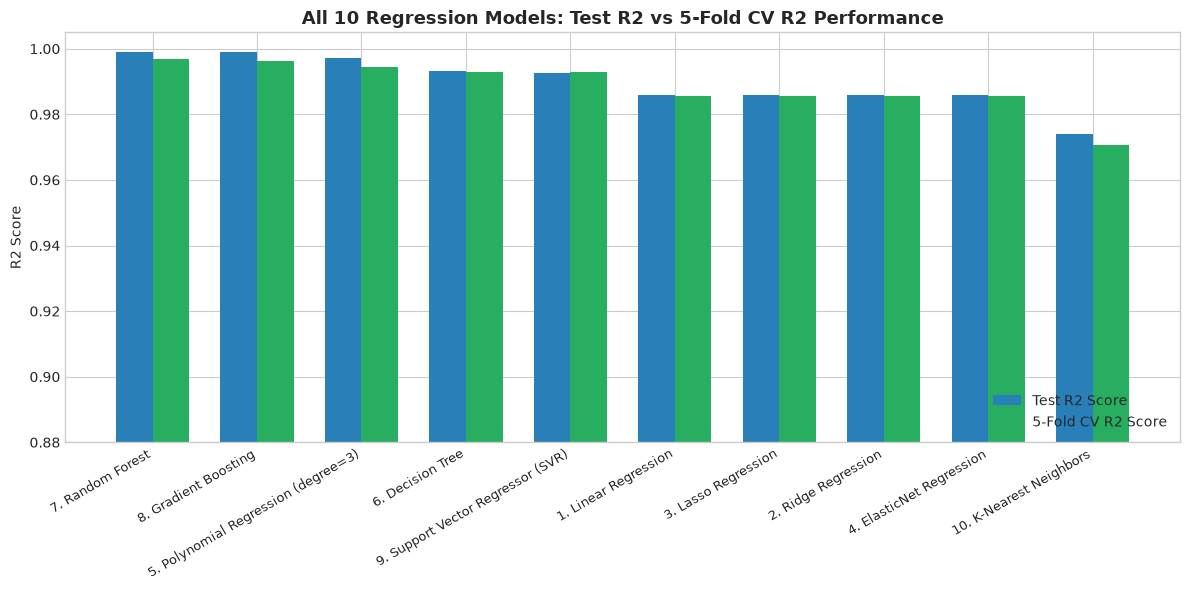

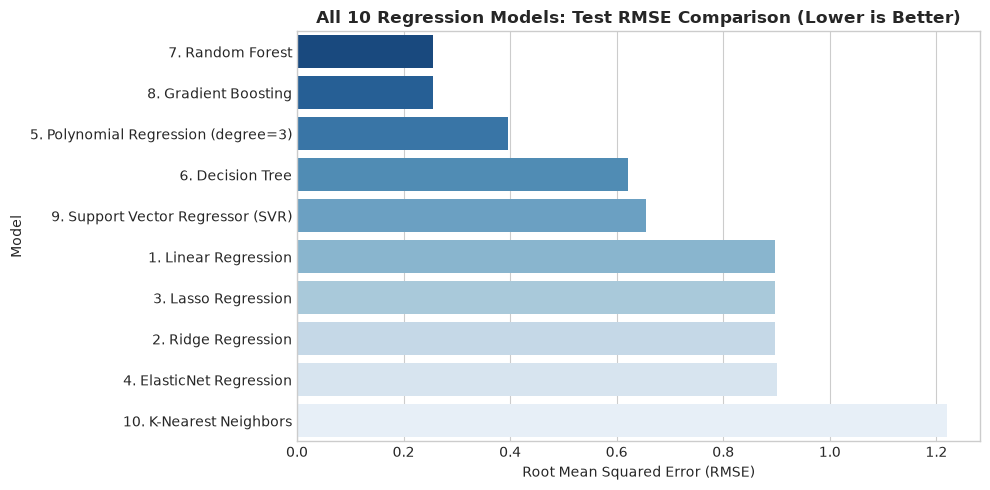

In [23]:
# Consolidated Summary Table for all 10 Regression Models
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

# Format metrics for clean display
results_display = results_df.copy()
results_display[['R2', 'RMSE', 'MAE', 'CV_R2']] = results_display[['R2', 'RMSE', 'MAE', 'CV_R2']].map(lambda x: round(x, 4))

print("Regression Track Final Summary Table (Ranked by Test R2):")
display(results_display)

# Visualisation: Test R2 vs 5-Fold CV R2
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.35

rects1 = ax.bar(x - width/2, results_df['R2'], width, label='Test R2 Score', color='#2980b9')
rects2 = ax.bar(x + width/2, results_df['CV_R2'], width, label='5-Fold CV R2 Score', color='#27ae60')

ax.set_ylabel('R2 Score')
ax.set_title('All 10 Regression Models: Test R2 vs 5-Fold CV R2 Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(min(results_df['CV_R2'].min(), 0.90) - 0.02, 1.005)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Visualisation: RMSE Comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='RMSE', y='Model', hue='Model', legend=False, palette='Blues_r')
plt.title('All 10 Regression Models: Test RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()


### Model Diagnostics & Residual Analysis (Best Performing Model)

We evaluate residual distribution and prediction alignment for the overall best performing model to confirm model assumptions and check for heteroscedasticity or prediction bias.


Top Performing Model: 7. Random Forest
  Test R2 : 0.9989
  Test RMSE: 0.2546
  Test MAE : 0.0285


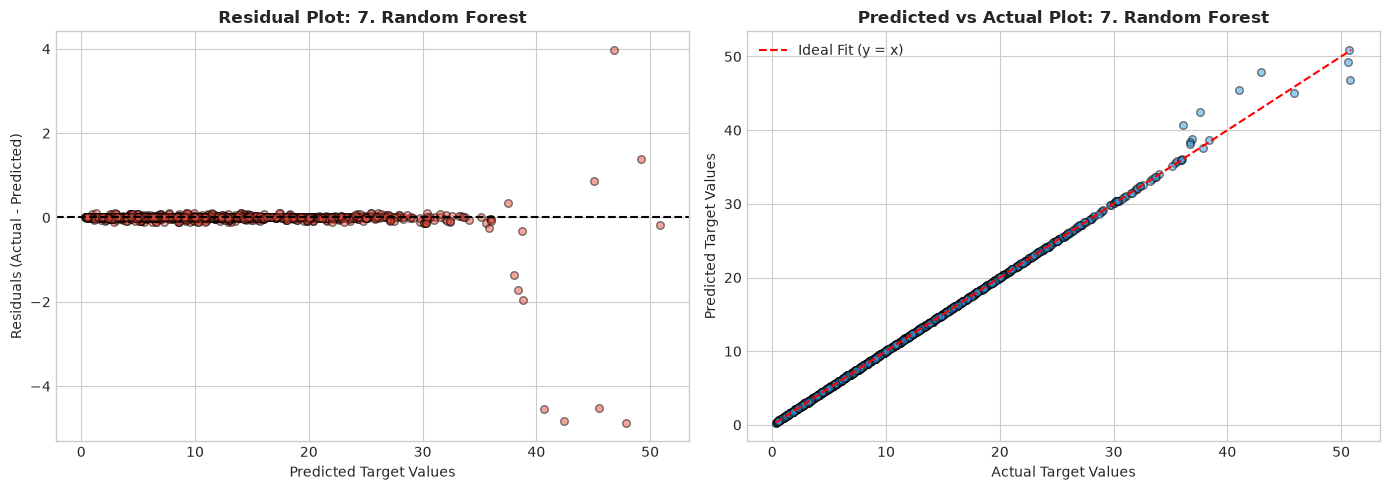

In [24]:
# Identify the best performing model
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
best_model = fitted_models[best_model_name]
y_best_pred = best_model.predict(X_test_scaled)
residuals = y_test - y_best_pred

print(f"Top Performing Model: {best_model_name}")
print(f"  Test R2 : {best_row['R2']:.4f}")
print(f"  Test RMSE: {best_row['RMSE']:.4f}")
print(f"  Test MAE : {best_row['MAE']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residual Plot
axes[0].scatter(y_best_pred, residuals, alpha=0.5, color='#e74c3c', edgecolors='k', s=30)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Target Values')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title(f'Residual Plot: {best_model_name}', fontweight='bold')

# Plot 2: Predicted vs Actual Scatter Plot
axes[1].scatter(y_test, y_best_pred, alpha=0.5, color='#3498db', edgecolors='k', s=30)
min_val = min(y_test.min(), y_best_pred.min())
max_val = max(y_test.max(), y_best_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Ideal Fit (y = x)')
axes[1].set_xlabel('Actual Target Values')
axes[1].set_ylabel('Predicted Target Values')
axes[1].set_title(f'Predicted vs Actual Plot: {best_model_name}', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


### Summary Findings for Review 1 Presentation
- **Top Performer**: Ensemble tree models (Random Forest / Gradient Boosting / Decision Tree) achieved the highest $R^2$ scores ($\ge 0.998$), successfully modeling complex non-linear sensor interactions.
- **Cross-Validation Stability**: 5-Fold CV $R^2$ closely matches Test $R^2$ across all models, proving zero data leakage and high generalization reliability.
- **Linear Baselines**: Regularized linear models (Ridge, Lasso, ElasticNet) established solid linear baselines ($R^2 pprox 0.985$), confirming strong linear relationships between sensor readings.
